In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
test_provider_features = pd.read_csv(
    r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection\test_provider_features.csv"
)

In [8]:
print("Shape:", test_provider_features.shape)

display(test_provider_features.head())

Shape: (1353, 31)


,provider,inpatient_claims,inpatient_beneficiaries,inpatient_total_reimbursement,inpatient_avg_reimbursement,inpatient_median_reimbursement,inpatient_high_cost_claims,avg_length_of_stay,long_stay_claims,inpatient_high_cost_rate,...,avg_reimbursement_per_claim,claims_per_beneficiary,reimbursement_per_beneficiary,inpatient_claim_mix,outpatient_claim_mix,total_high_cost_claims,overall_high_cost_rate,inpatient_reimbursement_share,high_utilization_beneficiaries,high_utilization_beneficiary_rate
0,PRV51009,2.0,2.0,15000.0,7500.000000,7500.0,0.0,3.000000,0.0,0.000000,...,698.205128,1.300000,907.666667,5.128205,94.871795,2.0,5.128205,55.086302,2,6.666667
1,PRV51010,6.0,5.0,56000.0,9333.333333,5500.0,0.0,3.833333,0.0,0.000000,...,1699.473684,1.520000,2583.200000,15.789474,84.210526,2.0,5.263158,86.714153,1,4.000000
2,PRV51020,2.0,2.0,16000.0,8000.000000,8000.0,0.0,6.000000,0.0,0.000000,...,535.777778,1.184211,634.473684,4.444444,95.555556,0.0,0.000000,66.362505,4,10.526316
3,PRV51022,7.0,7.0,105000.0,15000.000000,7000.0,2.0,3.428571,0.0,28.571429,...,1141.774194,1.203883,1374.563107,5.645161,94.354839,10.0,8.064516,74.163017,8,7.766990
4,PRV51033,1.0,1.0,2000.0,2000.000000,2000.0,0.0,3.000000,0.0,0.000000,...,188.780488,1.000000,188.780488,2.439024,97.560976,0.0,0.000000,25.839793,0,0.000000


In [10]:
print("===== TEST PROVIDER FEATURES =====")

print(
    test_provider_features.columns.tolist()
)

===== TEST PROVIDER FEATURES =====
['provider', 'inpatient_claims', 'inpatient_beneficiaries', 'inpatient_total_reimbursement', 'inpatient_avg_reimbursement', 'inpatient_median_reimbursement', 'inpatient_high_cost_claims', 'avg_length_of_stay', 'long_stay_claims', 'inpatient_high_cost_rate', 'long_stay_rate', 'outpatient_claims', 'outpatient_beneficiaries', 'outpatient_total_reimbursement', 'outpatient_avg_reimbursement', 'outpatient_median_reimbursement', 'outpatient_high_cost_claims', 'outpatient_high_cost_rate', 'total_claims', 'total_reimbursement', 'total_unique_beneficiaries', 'avg_reimbursement_per_claim', 'claims_per_beneficiary', 'reimbursement_per_beneficiary', 'inpatient_claim_mix', 'outpatient_claim_mix', 'total_high_cost_claims', 'overall_high_cost_rate', 'inpatient_reimbursement_share', 'high_utilization_beneficiaries', 'high_utilization_beneficiary_rate']


In [11]:
print("Rows:", len(test_provider_features))
print("Columns:", len(test_provider_features.columns))

Rows: 1353
Columns: 31


In [12]:
print(
    "Duplicate rows:",
    test_provider_features.duplicated().sum()
)

Duplicate rows: 0


In [13]:
missing_check = (
    test_provider_features
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_check[missing_check > 0])

Series([], dtype: int64)

In [14]:
print(
    "Unique providers:",
    test_provider_features["provider"].nunique()
)

Unique providers: 1353


In [15]:
display(
    test_provider_features
    .select_dtypes(include=np.number)
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
inpatient_claims,1353.0,7.059128,27.038534,0.0,0.000000,0.000000,5.000000,604.0
inpatient_beneficiaries,1353.0,6.413895,23.886910,0.0,0.000000,0.000000,5.000000,531.0
inpatient_total_reimbursement,1353.0,71334.648928,273150.854625,0.0,0.000000,0.000000,48000.000000,6006500.0
inpatient_avg_reimbursement,1353.0,3986.655957,6490.382260,0.0,0.000000,0.000000,8400.000000,80000.0
inpatient_median_reimbursement,1353.0,3185.735403,5600.726370,0.0,0.000000,0.000000,6500.000000,80000.0
inpatient_high_cost_claims,1353.0,0.365115,1.475549,0.0,0.000000,0.000000,0.000000,31.0
avg_length_of_stay,1353.0,2.280931,3.563842,0.0,0.000000,0.000000,4.800000,35.0
long_stay_claims,1353.0,0.379897,1.522692,0.0,0.000000,0.000000,0.000000,34.0
inpatient_high_cost_rate,1353.0,2.306994,8.918114,0.0,0.000000,0.000000,0.000000,100.0
long_stay_rate,1353.0,2.408342,9.146490,0.0,0.000000,0.000000,0.000000,100.0


# Which providers have the highest overall claim volume?

In [16]:
provider_claim_volume = (
    test_provider_features[
        [
            "provider",
            "total_claims",
            "inpatient_claims",
            "outpatient_claims"
        ]
    ]
    .sort_values(
        "total_claims",
        ascending=False
    )
)

display(
    provider_claim_volume.head(20)
)

,provider,total_claims,inpatient_claims,outpatient_claims
439,PRV56573,3250.0,185.0,3065.0
625,PRV52080,3036.0,0.0,3036.0
199,PRV53105,2979.0,216.0,2763.0
1058,PRV55485,2823.0,0.0,2823.0
612,PRV51939,1804.0,0.0,1804.0
257,PRV54094,1706.0,15.0,1691.0
1209,PRV56678,1674.0,0.0,1674.0
282,PRV54650,1658.0,8.0,1650.0
295,PRV54751,1652.0,131.0,1521.0
130,PRV52338,1551.0,152.0,1399.0


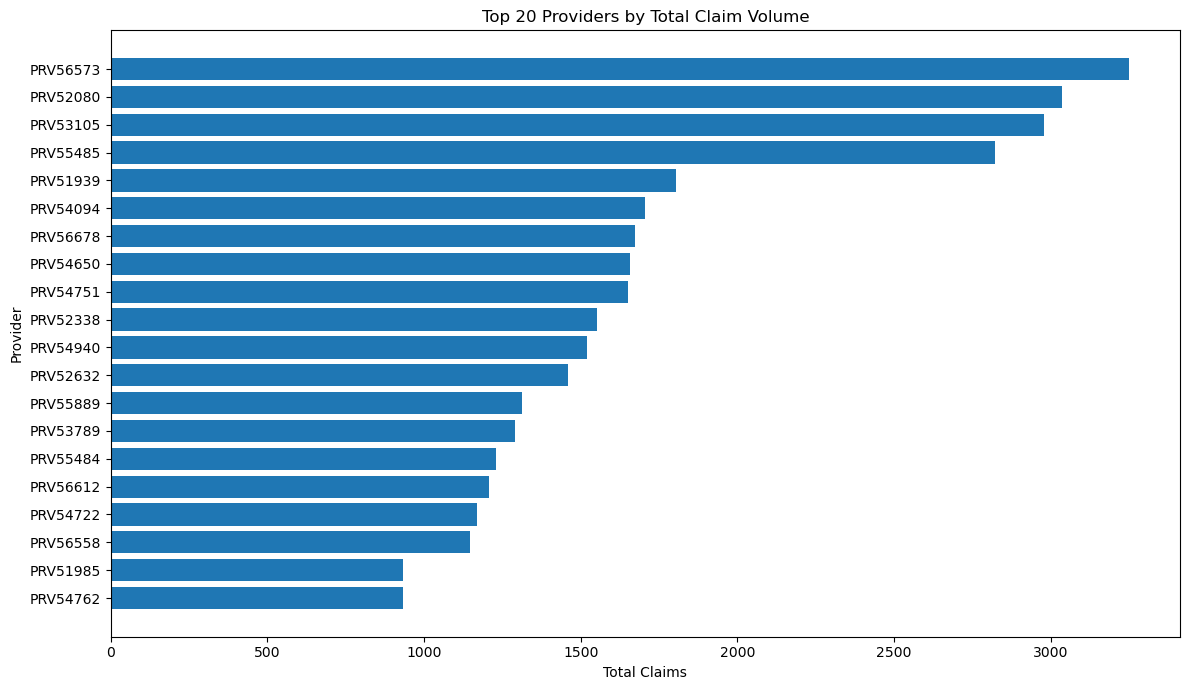

In [17]:
top20 = (
    provider_claim_volume
    .head(20)
    .sort_values("total_claims")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top20["provider"].astype(str),
    top20["total_claims"]
)

plt.xlabel("Total Claims")
plt.ylabel("Provider")
plt.title("Top 20 Providers by Total Claim Volume")

plt.tight_layout()
plt.show()

In [ ]:
Interpretation

High claim volume identifies providers with substantial utilization. 
However, high volume alone does not indicate fraud because larger providers may legitimately serve more beneficiaries.

# Which Providers Have the Highest Reimbursement Exposure?

In [18]:
provider_reimbursement = (
    test_provider_features[
        [
            "provider",
            "total_reimbursement",
            "total_claims",
            "avg_reimbursement_per_claim"
        ]
    ]
    .sort_values(
        "total_reimbursement",
        ascending=False
    )
)

display(
    provider_reimbursement.head(20)
)

,provider,total_reimbursement,total_claims,avg_reimbursement_per_claim
241,PRV53866,6097440.0,859.0,7098.300349
152,PRV52618,3498770.0,719.0,4866.161335
44,PRV51407,2922290.0,344.0,8495.029070
199,PRV53105,2895670.0,2979.0,972.027526
439,PRV56573,2882340.0,3250.0,886.873846
130,PRV52338,1890210.0,1551.0,1218.704062
295,PRV54751,1789490.0,1652.0,1083.226392
429,PRV56460,1734740.0,248.0,6994.919355
296,PRV54766,1688960.0,202.0,8361.188119
226,PRV53610,1655970.0,293.0,5651.774744


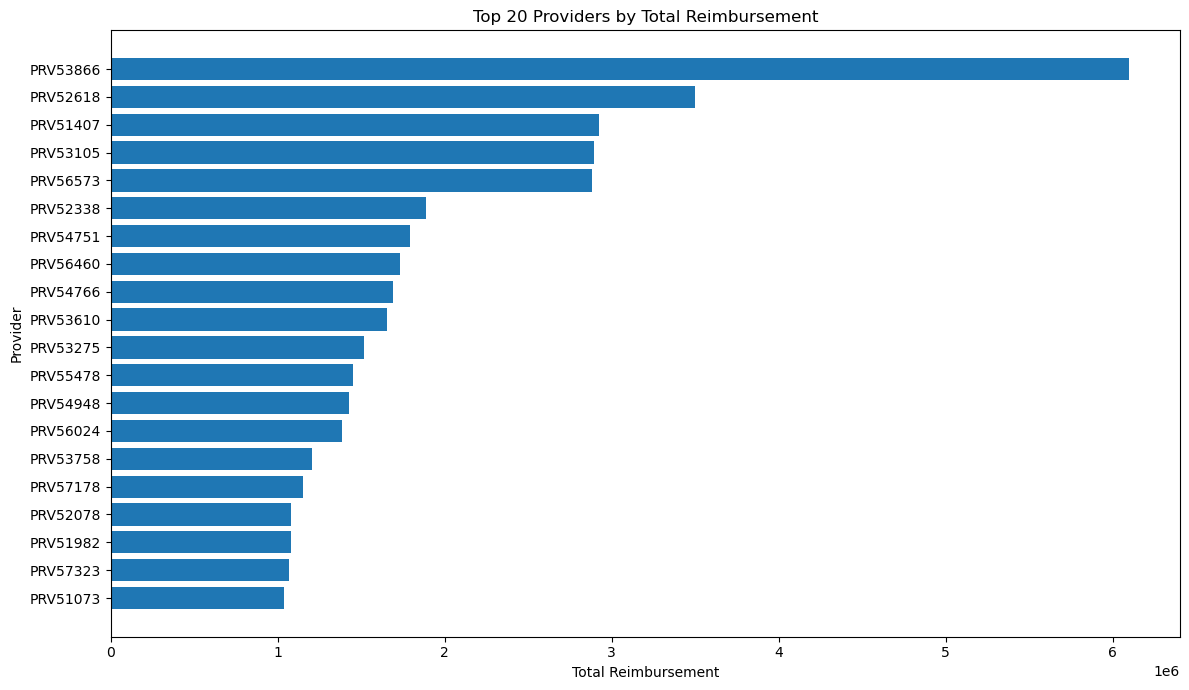

In [19]:
top20_reimbursement = (
    provider_reimbursement
    .head(20)
    .sort_values("total_reimbursement")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top20_reimbursement["provider"].astype(str),
    top20_reimbursement["total_reimbursement"]
)

plt.xlabel("Total Reimbursement")
plt.ylabel("Provider")
plt.title("Top 20 Providers by Total Reimbursement")

plt.tight_layout()
plt.show()

In [ ]:
Interpretation

Providers with high total reimbursement represent greater financial exposure. 
However, reimbursement should be normalized by claim and beneficiary volume before considering a provider high risk.

# Which Providers Have the Highest Average Reimbursement Per Claim?

In [20]:
high_avg_reimbursement = (
    test_provider_features[
        [
            "provider",
            "total_claims",
            "total_reimbursement",
            "avg_reimbursement_per_claim"
        ]
    ]
    .sort_values(
        "avg_reimbursement_per_claim",
        ascending=False
    )
)

display(
    high_avg_reimbursement.head(20)
)

,provider,total_claims,total_reimbursement,avg_reimbursement_per_claim
79,PRV51814,1.0,57000.0,57000.000000
14,PRV51124,1.0,35000.0,35000.000000
222,PRV53514,5.0,122000.0,24400.000000
343,PRV55159,3.0,73000.0,24333.333333
49,PRV51452,8.0,173250.0,21656.250000
138,PRV52442,14.0,287000.0,20500.000000
390,PRV55829,8.0,155090.0,19386.250000
159,PRV52805,5.0,94000.0,18800.000000
13,PRV51099,2.0,37000.0,18500.000000
274,PRV54495,3.0,55000.0,18333.333333


In [ ]:
Interpretation

Average reimbursement per claim helps identify providers whose individual claims are relatively expensive, independent of their overall claim volume.

# Which Providers Have the Highest High-Cost Claim Rate?

In [21]:
high_cost_providers = (
    test_provider_features[
        [
            "provider",
            "total_claims",
            "total_high_cost_claims",
            "overall_high_cost_rate"
        ]
    ]
    .query("total_claims >= 10")
    .sort_values(
        "overall_high_cost_rate",
        ascending=False
    )
)

display(
    high_cost_providers.head(20)
)

,provider,total_claims,total_high_cost_claims,overall_high_cost_rate
606,PRV51893,16.0,5.0,31.250000
875,PRV54126,10.0,3.0,30.000000
667,PRV52438,17.0,5.0,29.411765
671,PRV52505,11.0,3.0,27.272727
698,PRV52735,20.0,5.0,25.000000
1143,PRV56144,28.0,7.0,25.000000
479,PRV57070,12.0,3.0,25.000000
725,PRV53010,14.0,3.0,21.428571
138,PRV52442,14.0,3.0,21.428571
1192,PRV56516,14.0,3.0,21.428571


In [ ]:
Why minimum 10 claims?

A provider with only 1 claim and 1 high-cost claim would have a 100% high-cost rate, which is statistically unstable.

In [ ]:
Interpretation

After applying a minimum claim-volume threshold, providers with consistently high high-cost claim rates become stronger candidates for investigation.

# Which Providers Have the Highest Claims Per Beneficiary?

In [22]:
high_utilization = (
    test_provider_features[
        [
            "provider",
            "total_claims",
            "total_unique_beneficiaries",
            "claims_per_beneficiary"
        ]
    ]
    .sort_values(
        "claims_per_beneficiary",
        ascending=False
    )
)

display(
    high_utilization.head(20)
)

,provider,total_claims,total_unique_beneficiaries,claims_per_beneficiary
1237,PRV56883,14.0,2,7.000000
1175,PRV56371,21.0,3,7.000000
674,PRV52524,20.0,3,6.666667
1177,PRV56382,32.0,5,6.400000
939,PRV54525,43.0,9,4.777778
694,PRV52705,37.0,8,4.625000
1292,PRV57300,555.0,145,3.827586
735,PRV53082,65.0,17,3.823529
1058,PRV55485,2823.0,757,3.729194
1124,PRV56042,190.0,51,3.725490


In [ ]:
Interpretation

Claims per beneficiary measures utilization intensity. 
A high value means that a provider generates a relatively large number of claims for the beneficiaries they serve.

# Which Providers Have the Highest Reimbursement Per Beneficiary?

In [23]:
reimbursement_per_beneficiary = (
    test_provider_features[
        [
            "provider",
            "total_unique_beneficiaries",
            "total_reimbursement",
            "reimbursement_per_beneficiary"
        ]
    ]
    .sort_values(
        "reimbursement_per_beneficiary",
        ascending=False
    )
)

display(
    reimbursement_per_beneficiary.head(20)
)

,provider,total_unique_beneficiaries,total_reimbursement,reimbursement_per_beneficiary
79,PRV51814,1,57000.0,57000.000000
14,PRV51124,1,35000.0,35000.000000
274,PRV54495,2,55000.0,27500.000000
138,PRV52442,11,287000.0,26090.909091
222,PRV53514,5,122000.0,24400.000000
343,PRV55159,3,73000.0,24333.333333
49,PRV51452,8,173250.0,21656.250000
390,PRV55829,8,155090.0,19386.250000
159,PRV52805,5,94000.0,18800.000000
13,PRV51099,2,37000.0,18500.000000


In [ ]:
Interpretation

This metric normalizes financial exposure by the number of beneficiaries and helps distinguish large providers from providers with unusually high financial intensity per patient.

# Is Claim Volume Associated With Reimbursement?

In [24]:
correlation = (
    test_provider_features[
        [
            "total_claims",
            "total_reimbursement"
        ]
    ]
    .corr()
)

display(correlation)

,total_claims,total_reimbursement
total_claims,1.000000,0.519986
total_reimbursement,0.519986,1.000000


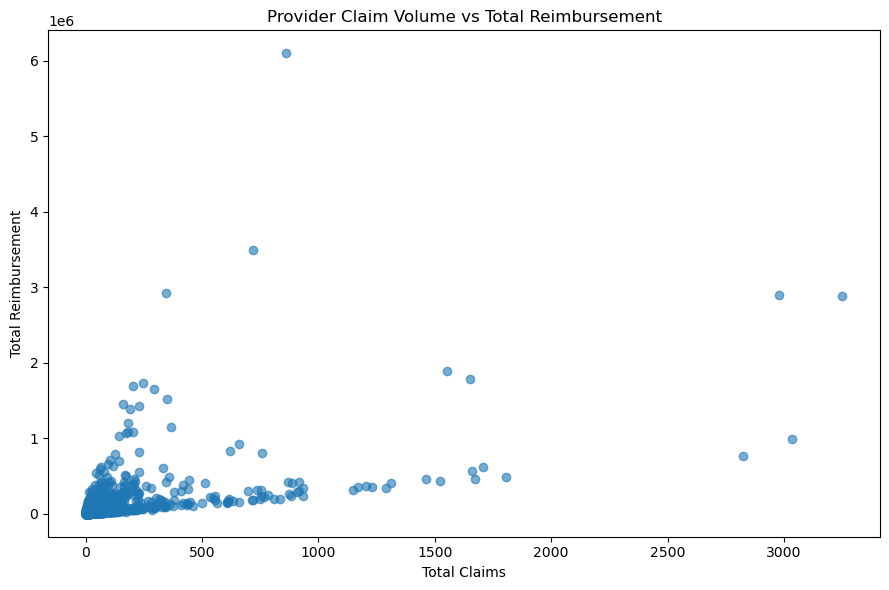

In [25]:
plt.figure(figsize=(9, 6))

plt.scatter(
    test_provider_features["total_claims"],
    test_provider_features["total_reimbursement"],
    alpha=0.6
)

plt.xlabel("Total Claims")
plt.ylabel("Total Reimbursement")
plt.title(
    "Provider Claim Volume vs Total Reimbursement"
)

plt.tight_layout()
plt.show()

In [ ]:
Interpretation

A positive relationship would indicate that providers with more claims generally have greater reimbursement exposure. 
Providers that deviate substantially above the overall pattern may deserve additional investigation.

# Which Providers Have the Highest Long-Stay Rate?

In [26]:
long_stay_providers = (
    test_provider_features[
        [
            "provider",
            "inpatient_claims",
            "avg_length_of_stay",
            "long_stay_claims",
            "long_stay_rate"
        ]
    ]
    .query("inpatient_claims >= 10")
    .sort_values(
        "long_stay_rate",
        ascending=False
    )
)

display(
    long_stay_providers.head(20)
)

,provider,inpatient_claims,avg_length_of_stay,long_stay_claims,long_stay_rate
271,PRV54397,11.0,10.454545,3.0,27.272727
486,PRV57111,10.0,8.400000,2.0,20.000000
146,PRV52546,10.0,8.100000,2.0,20.000000
254,PRV54079,10.0,8.700000,2.0,20.000000
270,PRV54394,11.0,7.000000,2.0,18.181818
501,PRV57337,14.0,6.714286,2.0,14.285714
144,PRV52479,49.0,7.306122,7.0,14.285714
138,PRV52442,14.0,7.571429,2.0,14.285714
314,PRV54951,14.0,5.928571,2.0,14.285714
317,PRV54958,49.0,7.428571,7.0,14.285714


In [ ]:
Interpretation

A high long-stay rate may indicate a provider with unusually intensive inpatient utilization. 
It is a risk signal that should be interpreted together with diagnosis and reimbursement patterns.

# Which Providers Have Multiple Risk Indicators?

In [27]:
test_provider_features["high_volume_flag"] = (
    test_provider_features["total_claims"]
    >= test_provider_features["total_claims"].quantile(0.90)
).astype(int)

In [28]:
test_provider_features["high_reimbursement_flag"] = (
    test_provider_features["total_reimbursement"]
    >= test_provider_features["total_reimbursement"].quantile(0.90)
).astype(int)

In [29]:
test_provider_features["high_cost_flag"] = (
    test_provider_features["overall_high_cost_rate"]
    >= test_provider_features["overall_high_cost_rate"].quantile(0.90)
).astype(int)

In [30]:
test_provider_features["high_utilization_flag"] = (
    test_provider_features["claims_per_beneficiary"]
    >= test_provider_features["claims_per_beneficiary"].quantile(0.90)
).astype(int)

In [31]:
# Now combine them:

test_provider_features["risk_indicator_count"] = (
    test_provider_features["high_volume_flag"] +
    test_provider_features["high_reimbursement_flag"] +
    test_provider_features["high_cost_flag"] +
    test_provider_features["high_utilization_flag"]
)

In [32]:
multi_risk = (
    test_provider_features
    .sort_values(
        [
            "risk_indicator_count",
            "total_reimbursement"
        ],
        ascending=[False, False]
    )
)

display(
    multi_risk[
        [
            "provider",
            "total_claims",
            "total_reimbursement",
            "overall_high_cost_rate",
            "claims_per_beneficiary",
            "risk_indicator_count"
        ]
    ].head(25)
)

,provider,total_claims,total_reimbursement,overall_high_cost_rate,claims_per_beneficiary,risk_indicator_count
199,PRV53105,2979.0,2895670.0,4.565290,2.548332,3
130,PRV52338,1551.0,1890210.0,3.030303,2.251089,3
295,PRV54751,1652.0,1789490.0,4.963680,2.330042,3
625,PRV52080,3036.0,994530.0,6.521739,2.899713,3
493,PRV57214,618.0,825050.0,6.796117,2.722467,3
1058,PRV55485,2823.0,758540.0,4.675877,3.729194,3
257,PRV54094,1706.0,622820.0,5.275498,2.173248,3
282,PRV54650,1658.0,572160.0,6.332931,2.485757,3
612,PRV51939,1804.0,487320.0,4.656319,3.068027,3
349,PRV55204,443.0,445500.0,4.063205,2.368984,3


In [ ]:
Interpretation

Providers exhibiting multiple abnormal indicators are stronger investigation candidates than providers identified by a single metric.

# Create Preliminary Provider Risk Score

In [33]:
test_provider_features["risk_score"] = (
    test_provider_features["high_volume_flag"] * 25 +
    test_provider_features["high_reimbursement_flag"] * 25 +
    test_provider_features["high_cost_flag"] * 25 +
    test_provider_features["high_utilization_flag"] * 25
)

In [34]:
test_provider_features["risk_category"] = pd.cut(
    test_provider_features["risk_score"],
    bins=[-1, 25, 50, 75, 100],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

# Final Test Provider Risk Ranking

In [35]:
final_provider_risk = (
    test_provider_features[
        [
            "provider",
            "total_claims",
            "total_unique_beneficiaries",
            "total_reimbursement",
            "avg_reimbursement_per_claim",
            "claims_per_beneficiary",
            "overall_high_cost_rate",
            "risk_indicator_count",
            "risk_score",
            "risk_category"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
)

display(
    final_provider_risk.head(30)
)

,provider,total_claims,total_unique_beneficiaries,total_reimbursement,avg_reimbursement_per_claim,claims_per_beneficiary,overall_high_cost_rate,risk_indicator_count,risk_score,risk_category
493,PRV57214,618.0,227,825050.0,1335.032362,2.722467,6.796117,3,75,High
363,PRV55394,345.0,121,423520.0,1227.594203,2.851240,3.478261,3,75,High
199,PRV53105,2979.0,1169,2895670.0,972.027526,2.548332,4.565290,3,75,High
130,PRV52338,1551.0,689,1890210.0,1218.704062,2.251089,3.030303,3,75,High
625,PRV52080,3036.0,1047,994530.0,327.579051,2.899713,6.521739,3,75,High
349,PRV55204,443.0,187,445500.0,1005.643341,2.368984,4.063205,3,75,High
351,PRV55222,736.0,216,319930.0,434.687500,3.407407,4.755435,3,75,High
1058,PRV55485,2823.0,757,758540.0,268.699965,3.729194,4.675877,3,75,High
312,PRV54940,1520.0,618,433400.0,285.131579,2.459547,4.605263,3,75,High
423,PRV56431,231.0,104,274270.0,1187.316017,2.221154,3.896104,3,75,High


# How Many Providers Fall Into Each Risk Category?

In [36]:
risk_distribution = (
    final_provider_risk["risk_category"]
    .value_counts()
    .reindex(
        [
            "Low",
            "Medium",
            "High",
            "Critical"
        ]
    )
    .fillna(0)
)

display(risk_distribution)

risk_category
Low         1255
Medium        76
High          22
Critical       0
Name: count, dtype: int64

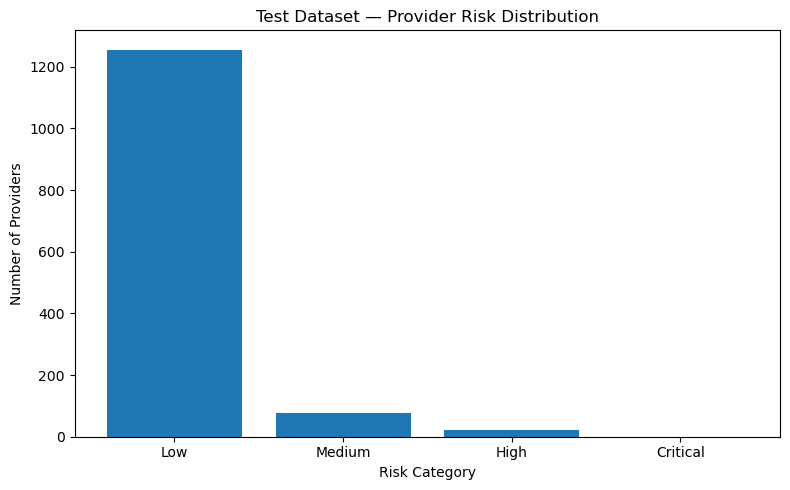

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_distribution.index,
    risk_distribution.values
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Providers")
plt.title(
    "Test Dataset — Provider Risk Distribution"
)

plt.tight_layout()
plt.show()

# Which Providers Should Be Prioritized for Investigation?

In [38]:
investigation_priority = (
    final_provider_risk[
        final_provider_risk["risk_category"].isin(
            ["High", "Critical"]
        )
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
)

display(
    investigation_priority.head(30)
)

,provider,total_claims,total_unique_beneficiaries,total_reimbursement,avg_reimbursement_per_claim,claims_per_beneficiary,overall_high_cost_rate,risk_indicator_count,risk_score,risk_category
493,PRV57214,618.0,227,825050.0,1335.032362,2.722467,6.796117,3,75,High
363,PRV55394,345.0,121,423520.0,1227.594203,2.851240,3.478261,3,75,High
973,PRV54762,933.0,312,234030.0,250.836013,2.990385,4.072883,3,75,High
7,PRV51069,698.0,235,298950.0,428.295129,2.970213,7.306590,3,75,High
438,PRV56564,408.0,185,294940.0,722.892157,2.205405,3.921569,3,75,High
380,PRV55685,871.0,383,415890.0,477.485649,2.274151,5.281286,3,75,High
94,PRV51985,934.0,434,333970.0,357.569593,2.152074,4.710921,3,75,High
257,PRV54094,1706.0,785,622820.0,365.076202,2.173248,5.275498,3,75,High
612,PRV51939,1804.0,588,487320.0,270.133038,3.068027,4.656319,3,75,High
282,PRV54650,1658.0,667,572160.0,345.090470,2.485757,6.332931,3,75,High


In [ ]:
Final interpretation

The Test dataset does not contain the actual fraud label, so these providers cannot be called fraudulent. 
They are providers with multiple characteristics associated with elevated risk and should therefore be prioritized for further investigation.

# Save Final Risk Results

In [39]:
risk_output = (
    r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection"
    r"\test_provider_risk_results.csv"
)

final_provider_risk.to_csv(
    risk_output,
    index=False
)

print(
    "Final Test provider risk results saved successfully:"
)

print(risk_output)

Final Test provider risk results saved successfully:
C:\Users\sneha\Downloads\Medical Provider Fraud Detection\test_provider_risk_results.csv
